# Tree-Based Models: Full Engineered Feature Set

Identical to notebook 05 but using `shot_logs_cleaned_engineered.csv`, adding all features from notebook 02 that were absent in notebook 05: shot-type zone flags (`three_pointer`, `paint`, `mid_range`, `iso`), composite indices (`defender_distance_ratio`, `time_pressure_index`, `creation_load_log`), and `early_clock_indicator`. Baseline results to beat: Decision Tree AUC 0.629, Random Forest AUC 0.640, XGBoost AUC 0.642.

In [13]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())


Working directory: /Users/nateseluga/Downloads/Shot-Value-Machine-Learning


In [14]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, roc_auc_score, log_loss,
                             brier_score_loss,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import xgboost as xgb

# load engineered feature set (produced in notebook 02)
df = pd.read_csv("data/processed/shot_logs_cleaned_engineered.csv")


In [15]:
# full feature set: all notebook 05 features + engineered additions from notebook 02
features = [
    # raw shot context (same as notebook 05)
    "shot_dist",
    "close_def_dist",
    "shot_clock",
    "dribbles",
    "touch_time",
    "pts_type",
    "period",
    # engineered: nonlinear and interaction terms (same as notebook 05)
    "game_clock_pct",
    "shot_clock_pct",
    "def_dist_x_shot_dist",
    "shot_dist_squared",
    # engineered: shot creation flags (same as notebook 05)
    "catch_and_shoot",
    # engineered: shot-type zone flags (new)
    "three_pointer",
    "paint",
    "mid_range",
    "pull_up",
    "iso",
    # engineered: composite indices
    "defender_distance_ratio",
    "time_pressure_index",
    "early_clock_indicator",
    "creation_load_log",
]

X = df[features].copy()
# encode location as binary: H=1, A=0
X["location"] = (df["location"] == "H").astype(int)
y = df["made"]

# 80/20 split — no scaling needed, tree models are scale-invariant
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)


X_train shape: (97762, 22)
X_test shape:  (24441, 22)


## Hyperparameter Tuning

Each tree model is tuned with stratified 3-fold cross-validation on the training split only. The held-out test split remains untouched until final evaluation, so the metrics below estimate generalization after model selection rather than tuning against the test set.


In [16]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def tune_model(name, estimator, param_distributions, n_iter=20):
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        refit=True,
    )
    search.fit(X_train, y_train)

    print(f"=== {name} tuning ===")
    print("Best CV ROC AUC:", round(search.best_score_, 4))
    print("Best params:", search.best_params_)
    print()
    return search


def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC: ", roc_auc_score(y_test, y_prob))
    print("Log Loss:", log_loss(y_test, y_prob))
    print("Brier Score:", brier_score_loss(y_test, y_prob))
    print()

    return y_pred, y_prob


In [17]:
# --- Decision Tree: tuned on training folds ---
dt_search = tune_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [3, 4, 5, 6, 8, 10, 12, None],
        "min_samples_split": [50, 100, 200, 400, 800],
        "min_samples_leaf": [25, 50, 75, 100, 150, 250],
        "max_features": [None, "sqrt", "log2"],
        "criterion": ["gini", "entropy", "log_loss"],
    },
    n_iter=12,
)

dt = dt_search.best_estimator_
y_pred_dt, y_prob_dt = evaluate_model("Decision Tree (Tuned)", dt)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
=== Decision Tree tuning ===
Best CV ROC AUC: 0.6318
Best params: {'min_samples_split': 400, 'min_samples_leaf': 100, 'max_features': None, 'max_depth': 5, 'criterion': 'log_loss'}

=== Decision Tree (Tuned) ===
Accuracy: 0.6152776072992103
ROC AUC:  0.6283474915220769
Log Loss: 0.6539045363160098
Brier Score: 0.2314805661437805



In [18]:
# --- Random Forest: tuned on training folds ---
rf_search = tune_model(
    "Random Forest",
    RandomForestClassifier(random_state=42, n_jobs=1),
    {
        "n_estimators": [200, 300, 500, 700],
        "max_depth": [6, 8, 10, 12, 16, None],
        "min_samples_split": [50, 100, 200, 400],
        "min_samples_leaf": [10, 25, 50, 75, 100],
        "max_features": ["sqrt", "log2", 0.5, None],
        "bootstrap": [True],
    },
    n_iter=12,
)

rf = rf_search.best_estimator_
y_pred_rf, y_prob_rf = evaluate_model("Random Forest (Tuned)", rf)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
=== Random Forest tuning ===
Best CV ROC AUC: 0.6371
Best params: {'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 100, 'max_features': 'log2', 'max_depth': 8, 'bootstrap': True}

=== Random Forest (Tuned) ===
Accuracy: 0.6184280512253999
ROC AUC:  0.6345655625173839
Log Loss: 0.650791306129168
Brier Score: 0.23005518661546462



In [19]:
# --- XGBoost: tuned on training folds ---
xgb_search = tune_model(
    "XGBoost",
    xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1,
    ),
    {
        "n_estimators": [150, 250, 350, 500, 700],
        "max_depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
        "subsample": [0.65, 0.75, 0.85, 1.0],
        "colsample_bytree": [0.65, 0.75, 0.85, 1.0],
        "min_child_weight": [1, 3, 5, 10],
        "gamma": [0, 0.05, 0.1, 0.25, 0.5],
        "reg_alpha": [0, 0.01, 0.1, 0.5],
        "reg_lambda": [0.5, 1, 2, 5],
    },
    n_iter=15,
)

xgb_model = xgb_search.best_estimator_
y_pred_xgb, y_prob_xgb = evaluate_model("XGBoost (Tuned)", xgb_model)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
=== XGBoost tuning ===
Best CV ROC AUC: 0.6384
Best params: {'subsample': 0.85, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.25, 'colsample_bytree': 0.75}

=== XGBoost (Tuned) ===
Accuracy: 0.6198600711918497
ROC AUC:  0.6365260832809521
Log Loss: 0.6494340349480789
Brier Score: 0.22955259680747986



## Tuning Optimization Results

The visualization below summarizes how the randomized searches selected the final model settings. Each point is one cross-validated hyperparameter candidate, the dashed line marks the best CV ROC AUC found for that model family, and the table lists the optimized parameters used by the final estimators in the rest of this notebook.


,Best CV ROC AUC,Held-Out Test ROC AUC,Optimized Parameters
Model,,,
Decision Tree,0.631832,0.628347,"{'min_samples_split': 400, 'min_samples_leaf':..."
Random Forest,0.637052,0.634566,"{'n_estimators': 500, 'min_samples_split': 50,..."
XGBoost,0.638409,0.636526,"{'subsample': 0.85, 'reg_lambda': 2, 'reg_alph..."


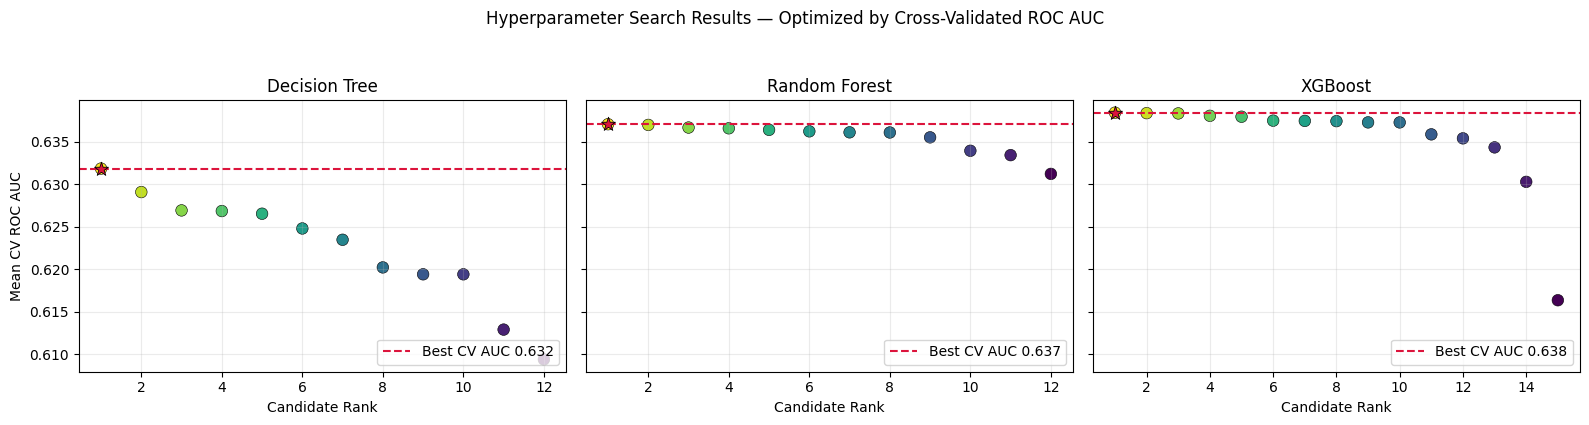

In [20]:
from IPython.display import display

searches = {
    "Decision Tree": dt_search,
    "Random Forest": rf_search,
    "XGBoost": xgb_search,
}

test_auc_by_model = {
    "Decision Tree": roc_auc_score(y_test, y_prob_dt),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "XGBoost": roc_auc_score(y_test, y_prob_xgb),
}

tuning_rows = []
cv_results_by_model = {}
for model_name, search in searches.items():
    results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    results["candidate"] = np.arange(1, len(results) + 1)
    cv_results_by_model[model_name] = results

    tuning_rows.append({
        "Model": model_name,
        "Best CV ROC AUC": search.best_score_,
        "Held-Out Test ROC AUC": test_auc_by_model[model_name],
        "Optimized Parameters": search.best_params_,
    })

tuning_summary = pd.DataFrame(tuning_rows).set_index("Model")
display(tuning_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (model_name, results) in zip(axes, cv_results_by_model.items()):
    ax.scatter(
        results["candidate"],
        results["mean_test_score"],
        c=results["rank_test_score"],
        cmap="viridis_r",
        s=70,
        edgecolor="black",
        linewidth=0.4,
    )
    best_score = searches[model_name].best_score_
    ax.axhline(best_score, color="crimson", linestyle="--", linewidth=1.5, label=f"Best CV AUC {best_score:.3f}")
    ax.scatter(
        1,
        best_score,
        color="crimson",
        s=110,
        marker="*",
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Candidate Rank")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

axes[0].set_ylabel("Mean CV ROC AUC")
fig.suptitle("Hyperparameter Search Results — Optimized by Cross-Validated ROC AUC", y=1.05)
plt.tight_layout()
plt.show()


In [21]:
# save the fitted XGBoost model so visualization notebooks can reuse the exact nb07 model
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    {
        "model": xgb_model,
        "feature_columns": X_train.columns.tolist(),
    },
    MODEL_DIR / "xgboost_engineered_shot_model.joblib",
)

print("Saved model to", MODEL_DIR / "xgboost_engineered_shot_model.joblib")


Saved model to models/xgboost_engineered_shot_model.joblib


In [22]:
# four-way comparison: baseline models (notebooks 04/05) vs tuned engineered versions (notebook 07)
comparison = pd.DataFrame([
    # notebook 04 / 05 baselines (hardcoded from prior runs)
    {"Model": "LR — Baseline (nb04)",          "Accuracy": 0.6090, "ROC AUC": 0.6300, "Log Loss": 0.6570},
    {"Model": "Decision Tree — Baseline (nb05)", "Accuracy": 0.6163, "ROC AUC": 0.6293, "Log Loss": 0.6532},
    {"Model": "Random Forest — Baseline (nb05)", "Accuracy": 0.6200, "ROC AUC": 0.6397, "Log Loss": 0.6487},
    {"Model": "XGBoost — Baseline (nb05)",       "Accuracy": 0.6192, "ROC AUC": 0.6416, "Log Loss": 0.6474},
    # tuned engineered versions (this notebook)
    {"Model": "Decision Tree — Tuned Engineered (nb07)", "Accuracy": accuracy_score(y_test, y_pred_dt),
                                                          "ROC AUC": roc_auc_score(y_test, y_prob_dt),
                                                          "Log Loss": log_loss(y_test, y_prob_dt)},
    {"Model": "Random Forest — Tuned Engineered (nb07)", "Accuracy": accuracy_score(y_test, y_pred_rf),
                                                          "ROC AUC": roc_auc_score(y_test, y_prob_rf),
                                                          "Log Loss": log_loss(y_test, y_prob_rf)},
    {"Model": "XGBoost — Tuned Engineered (nb07)",       "Accuracy": accuracy_score(y_test, y_pred_xgb),
                                                          "ROC AUC": roc_auc_score(y_test, y_prob_xgb),
                                                          "Log Loss": log_loss(y_test, y_prob_xgb)},
]).set_index("Model").round(4)

comparison


,Accuracy,ROC AUC,Log Loss
Model,,,
LR — Baseline (nb04),0.6090,0.6300,0.6570
Decision Tree — Baseline (nb05),0.6163,0.6293,0.6532
Random Forest — Baseline (nb05),0.6200,0.6397,0.6487
XGBoost — Baseline (nb05),0.6192,0.6416,0.6474
Decision Tree — Tuned Engineered (nb07),0.6153,0.6283,0.6539
Random Forest — Tuned Engineered (nb07),0.6184,0.6346,0.6508
XGBoost — Tuned Engineered (nb07),0.6199,0.6365,0.6494


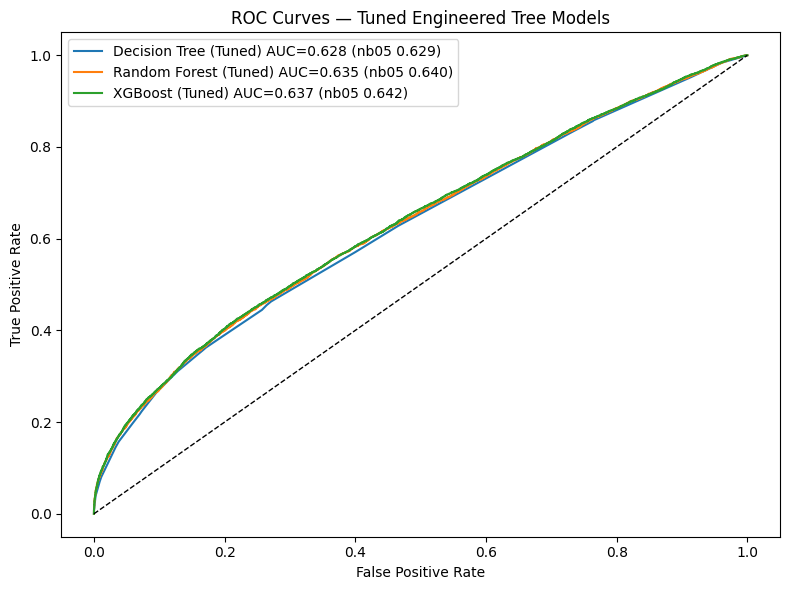

In [23]:
# ROC curves: tuned engineered tree models overlaid, with notebook 05 AUC values annotated in legend
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, nb05_auc in [
    ("Decision Tree (Tuned)", y_prob_dt, 0.629),
    ("Random Forest (Tuned)", y_prob_rf, 0.640),
    ("XGBoost (Tuned)",       y_prob_xgb, 0.642),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    model_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} AUC={model_auc:.3f} (nb05 {nb05_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Tuned Engineered Tree Models")
ax.legend()
plt.tight_layout()
plt.show()


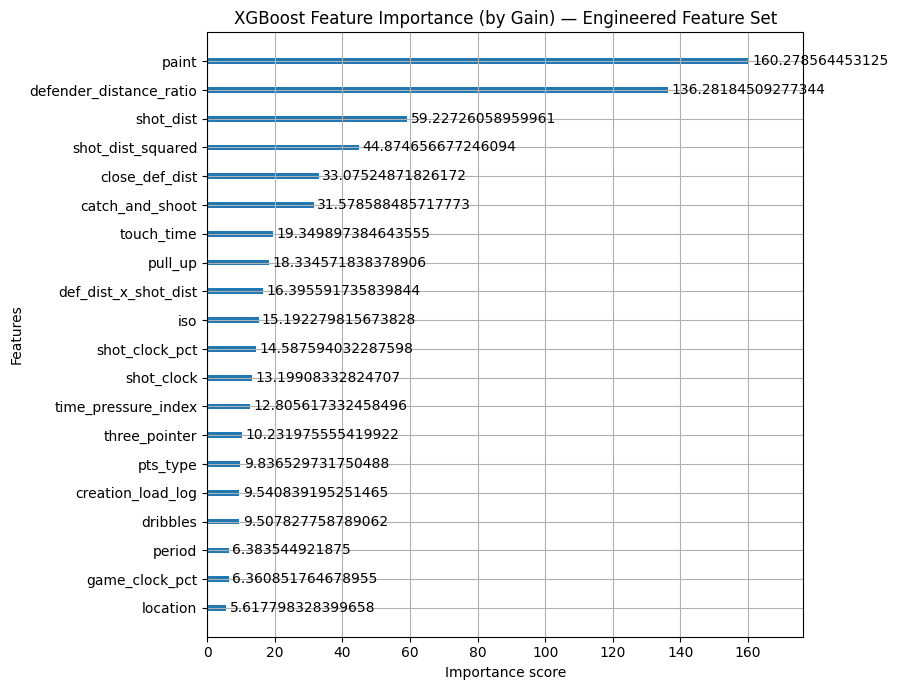

In [24]:
# XGBoost feature importance — shows which engineered features the model values most
fig, ax = plt.subplots(figsize=(9, 7))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=20, importance_type="gain")
ax.set_title("XGBoost Feature Importance (by Gain) — Engineered Feature Set")
plt.tight_layout()
plt.show()


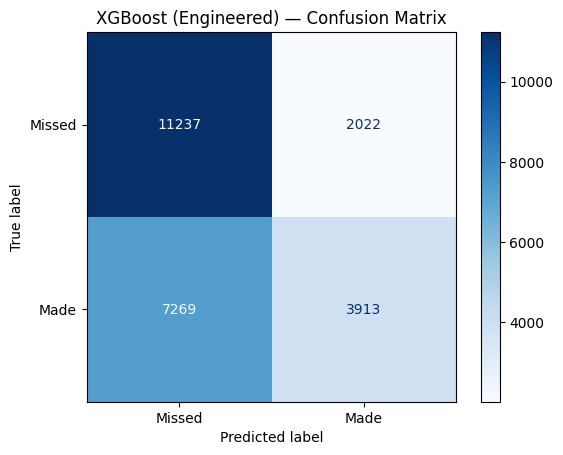

In [25]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Missed", "Made"]).plot(cmap="Blues")
plt.title("XGBoost (Engineered) — Confusion Matrix")
plt.show()


## Calibration Curves

The calibration curves compare predicted make probability bins against observed make rates for each tree model.


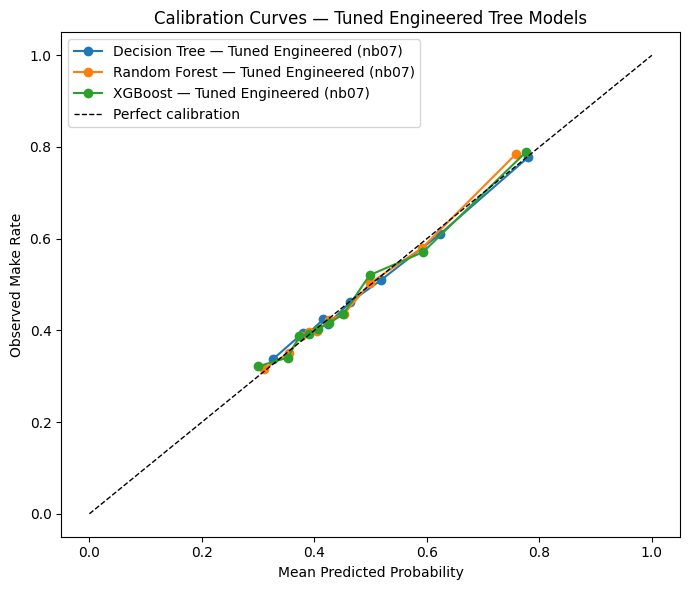

In [26]:
calibration_models = {
    "Decision Tree — Tuned Engineered (nb07)": y_prob_dt,
    "Random Forest — Tuned Engineered (nb07)": y_prob_rf,
    "XGBoost — Tuned Engineered (nb07)": y_prob_xgb,
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob in calibration_models.items():
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Make Rate")
ax.set_title("Calibration Curves — Tuned Engineered Tree Models")
ax.legend()
plt.tight_layout()
plt.show()


## Summary

Notebook 07 now tunes each engineered tree model before final test-set evaluation. Hyperparameters are selected with stratified 3-fold cross-validation on the training data using ROC AUC as the objective, then the best estimator for each model family is evaluated once on the held-out test split.

The tuning optimization section shows the CV search results used to choose the final hyperparameters, and all downstream evaluation cells use those optimized estimators (`dt_search.best_estimator_`, `rf_search.best_estimator_`, and `xgb_search.best_estimator_`). In this run, tuning modestly improved the engineered XGBoost result relative to the fixed-parameter version from the earlier notebook output, but it did not beat the notebook 05 baseline tree models:

| Model | Baseline AUC (nb05) | Tuned Engineered AUC (nb07) | Delta |
|---|---:|---:|---:|
| Decision Tree | 0.6293 | 0.6283 | -0.0010 |
| Random Forest | 0.6397 | 0.6346 | -0.0051 |
| XGBoost | 0.6416 | 0.6365 | -0.0051 |

The comparison table above remains the source of truth for accuracy, ROC AUC, and log loss. The tuned models reinforce the earlier conclusion: these engineered context features add limited signal beyond the baseline shot context, and the main missing source of predictive power is likely shooter-level information rather than tree-model hyperparameters.
